# EDA(Explorartory Data Analysis)
Conducted a comprehensive Exploratory Data Analysis (EDA) on a loan default dataset to identify patterns and risk factors associated with borrower defaults. The analysis involved data quality assessment, missing value treatment, duplicate detection, descriptive statistics, and the exploration of borrower demographics, income, loan characteristics, credit history, and repayment behavior. Key insights were generated by examining default rates across loan purposes, loan grades, home ownership categories, and previous credit history. Correlation analysis highlighted the numerical variables most associated with loan default, providing valuable guidance for feature engineering and predictive modeling. The findings were documented with actionable business recommendations, laying the foundation for developing a machine learning model, an interactive Power BI dashboard, and a REST API for loan default prediction.

In [1]:
import pandas as pd
import numpy as np

df =  pd.read_csv("cleaned_risk.csv")
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
df.shape

(32581, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.000000,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.000000,79200.00,6000000.00
person_emp_length,32581.0,4.767994,4.087372,0.00,2.00,4.000000,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.000000,12200.00,35000.00
loan_int_rate,32581.0,11.011695,3.081605,5.42,8.49,11.011695,13.11,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.000000,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.150000,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.000000,8.00,30.00


In [6]:
df.describe(include='object').T

,count,unique,top,freq
person_home_ownership,32581,4,RENT,16446
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
cb_person_default_on_file,32581,2,N,26836


In [7]:
df.duplicated().sum()

np.int64(165)

In [8]:
df = df.drop_duplicates()

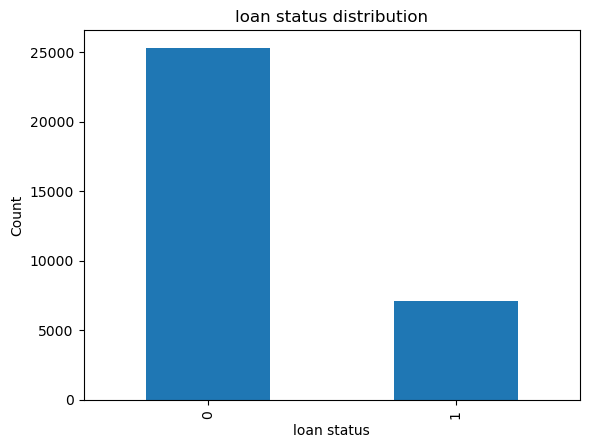

In [10]:
import matplotlib.pyplot as plt
df["loan_status"].value_counts().plot(kind='bar')
plt.title("loan status distribution")
plt.xlabel('loan status')
plt.ylabel('Count')
plt.show()

In [11]:
df["loan_status"].value_counts(normalize=True)*100

loan_status
0    78.13117
1    21.86883
Name: proportion, dtype: float64

In [12]:
numerical_cols = df.select_dtypes(include=["int64", "Float64"]).columns
numerical_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

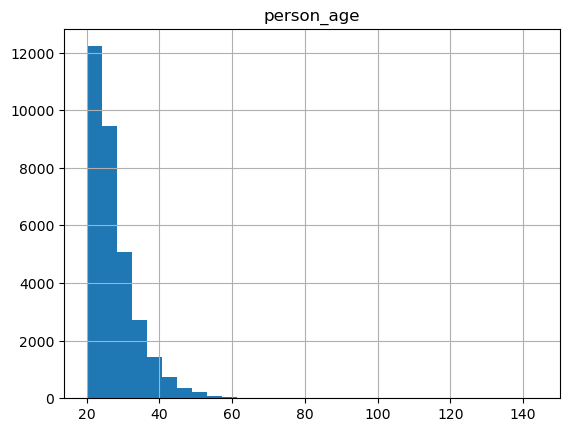

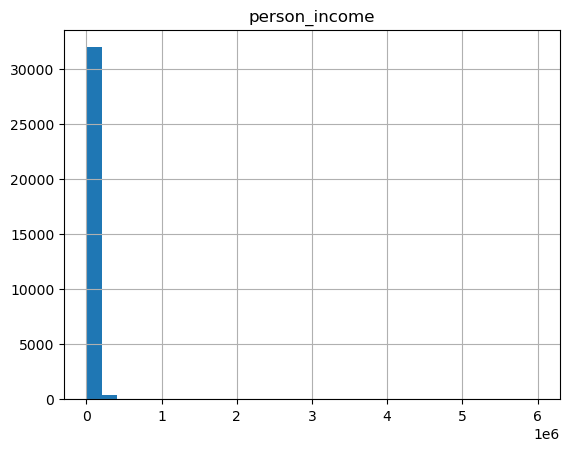

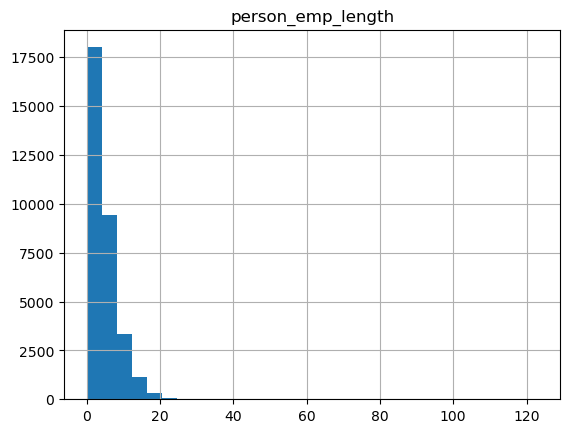

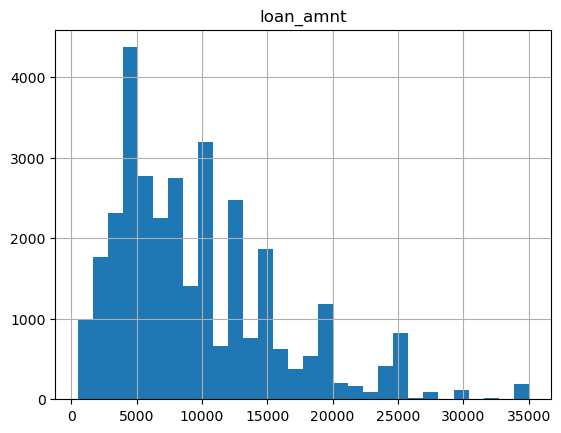

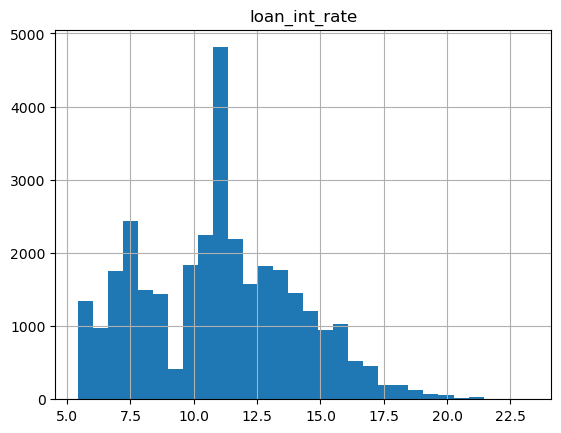

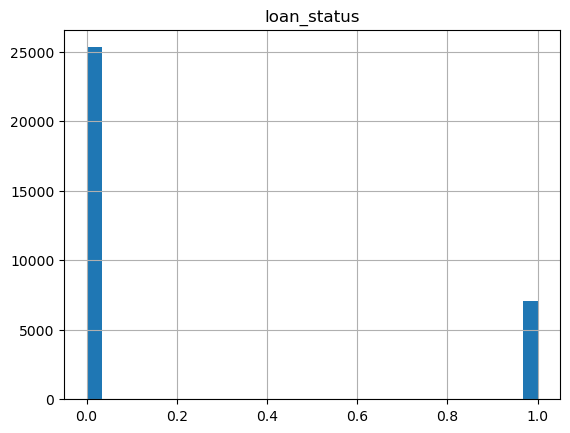

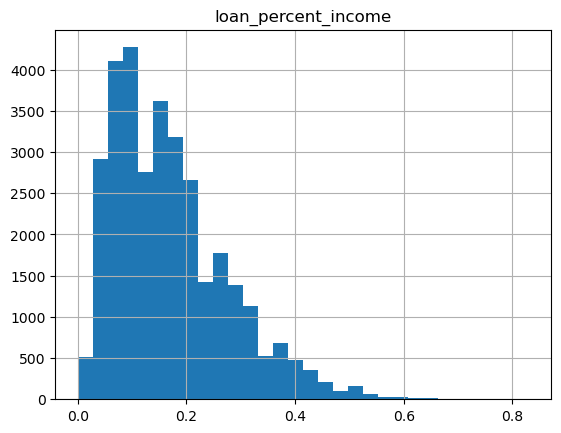

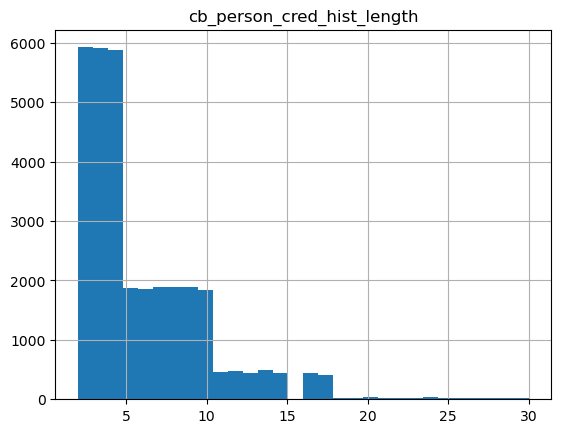

In [13]:
for col in numerical_cols:
    plt.Figure(figsize=(6,2))
    df[col].hist(bins=30)
    plt.title(col)
    plt.show()

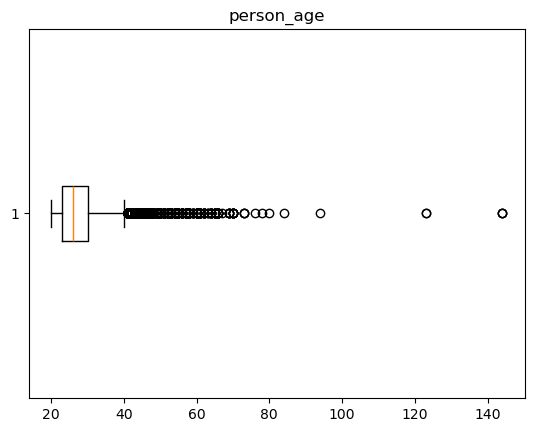

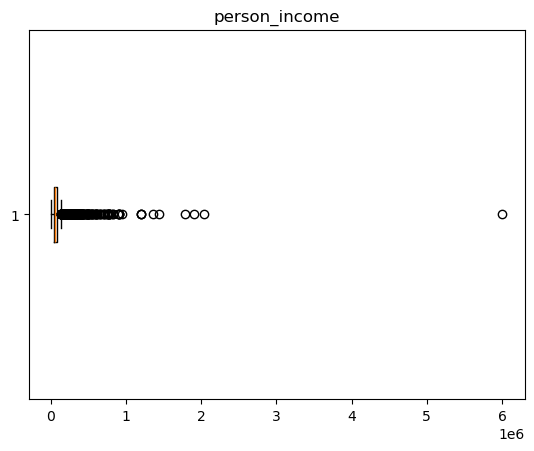

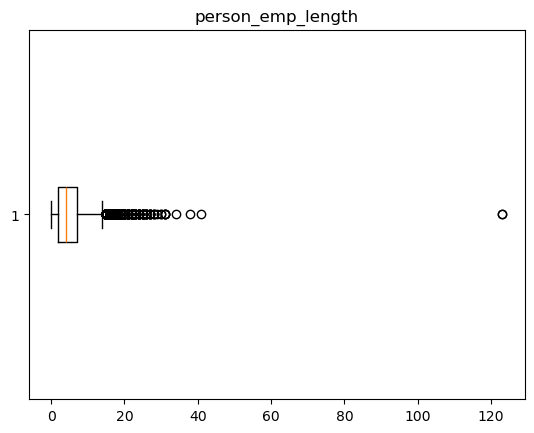

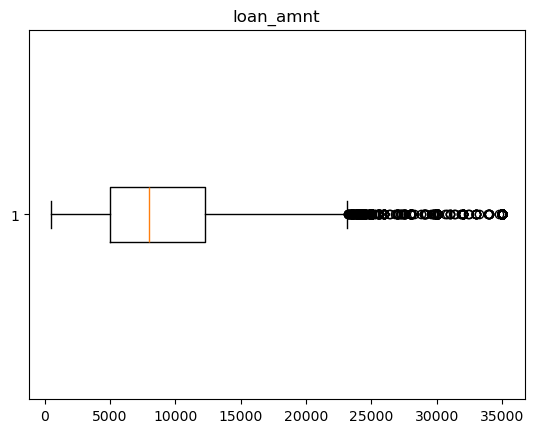

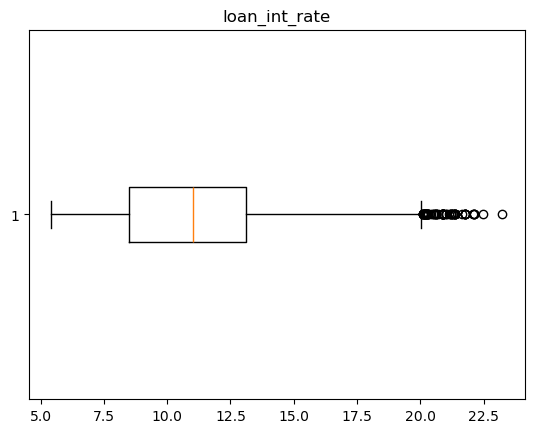

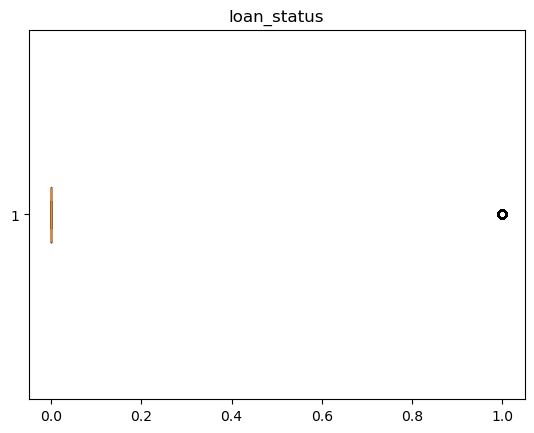

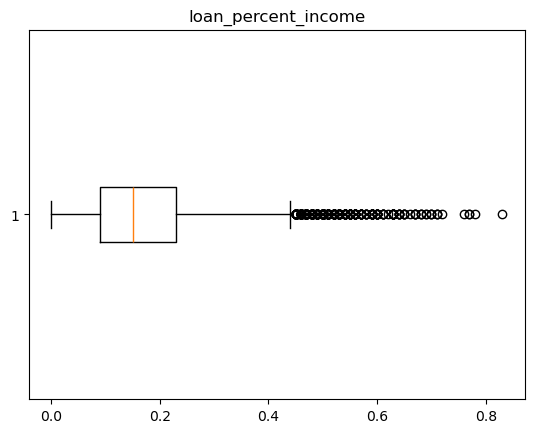

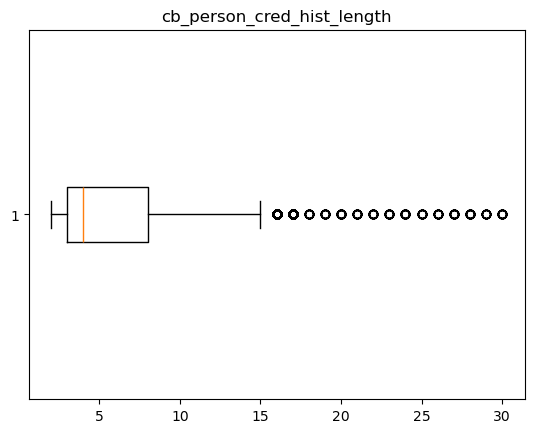

In [14]:
for col in numerical_cols:
    plt.Figure(figsize=(6,2))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

In [15]:
Categorical_cols = df.select_dtypes(include=["object"]).columns
Categorical_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

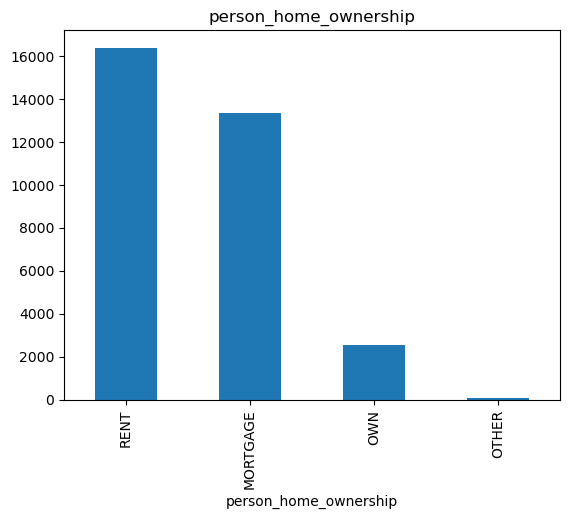

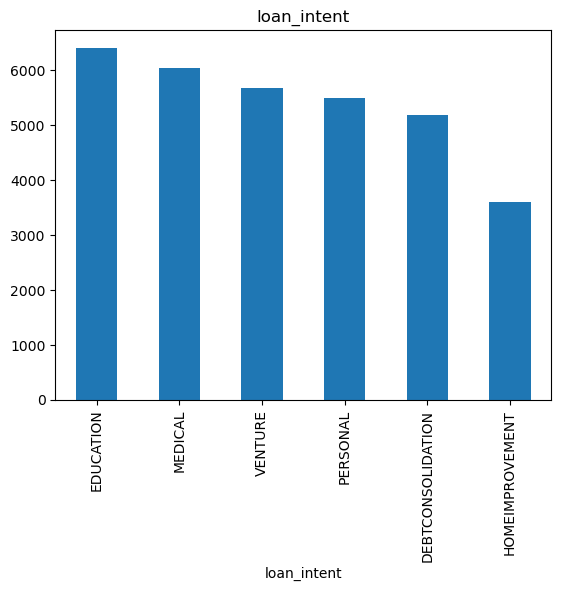

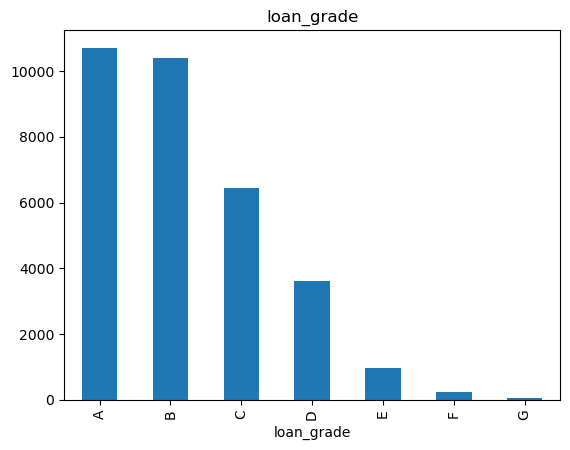

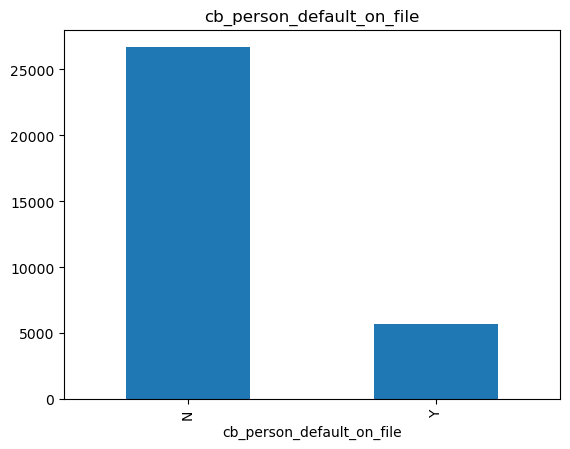

In [16]:
for col in Categorical_cols:
    plt.Figure(figsize=(7,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.show()

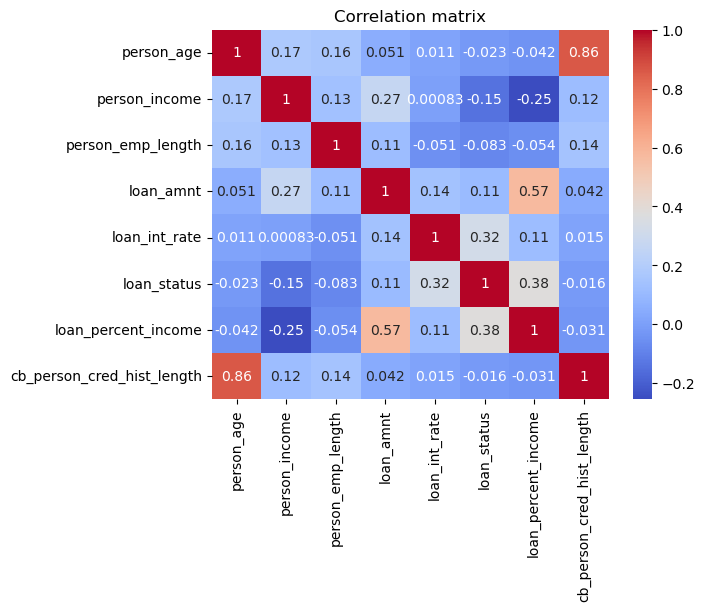

In [17]:
import seaborn as sns
plt.Figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only= True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

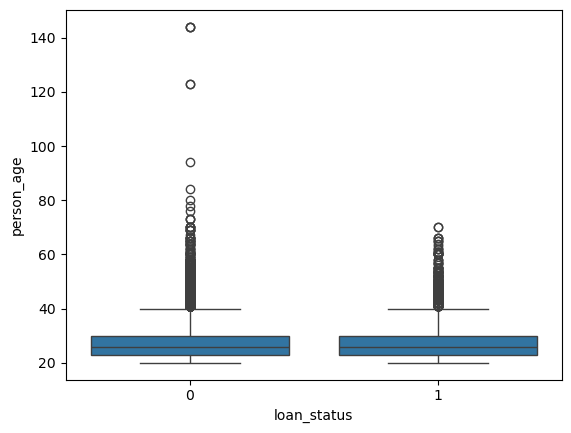

In [18]:
import seaborn as sns

sns.boxplot(
    x = "loan_status",
    y = "person_age",
    data = df
)
plt.show()

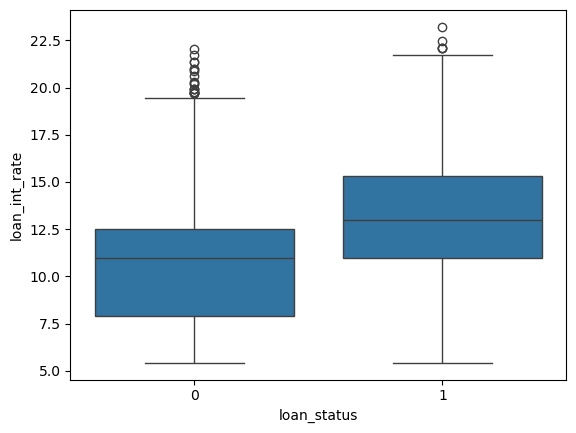

In [19]:
sns.boxplot(
    x = "loan_status",
    y = "loan_int_rate",
    data = df
)
plt.show()

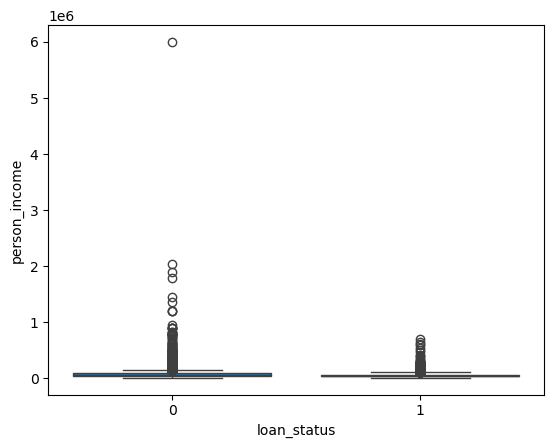

In [20]:
sns.boxplot(
    x = "loan_status",
    y = "person_income",
    data = df
)
plt.show()

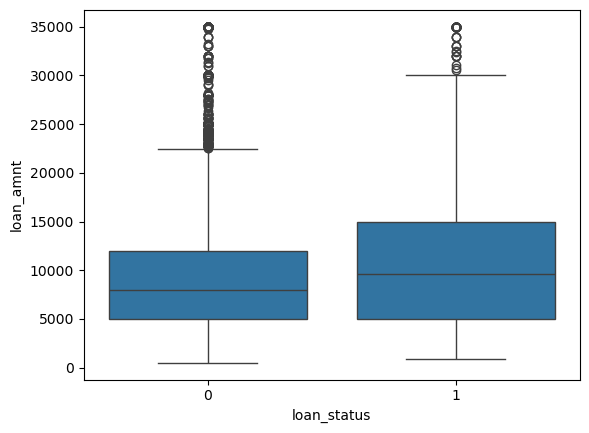

In [22]:
sns.boxplot(
    x = "loan_status",
    y = "loan_amnt",
    data = df
)
plt.show()

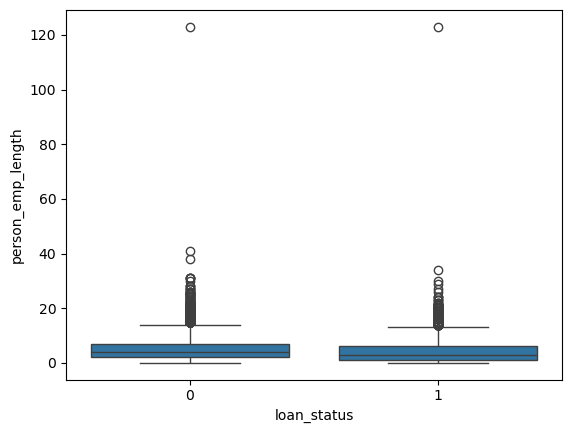

In [23]:
sns.boxplot(
    x = "loan_status",
    y = "person_emp_length",
    data = df
)
plt.show()

<Axes: xlabel='person_home_ownership'>

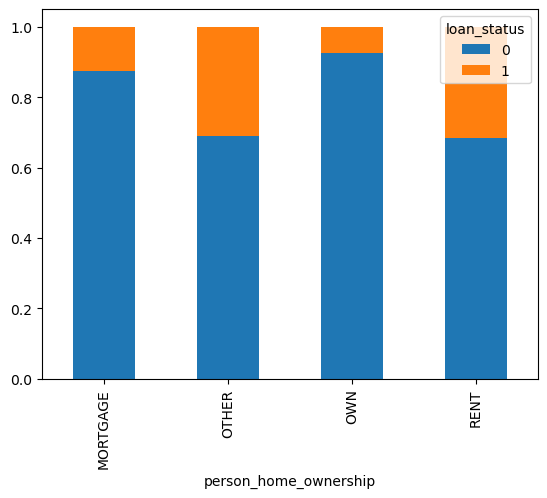

In [24]:
pd.crosstab(
    df["person_home_ownership"],
    df["loan_status"],
    normalize="index"
).plot(kind="bar", stacked= True)

<Axes: xlabel='loan_intent'>

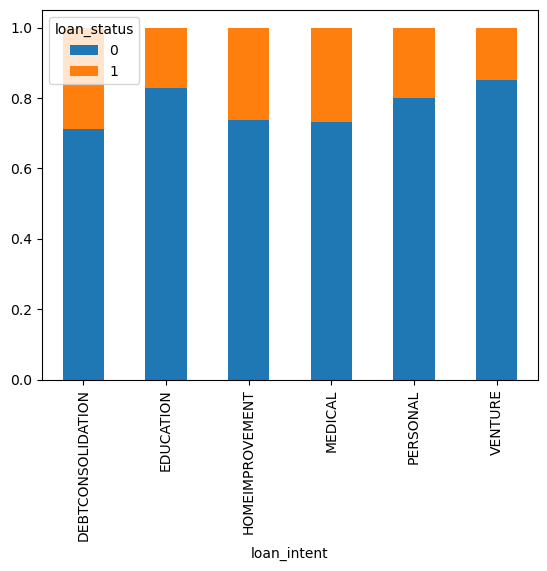

In [25]:
pd.crosstab(
    df["loan_intent"],
    df["loan_status"],
    normalize="index"
).plot(kind="bar", stacked= True)

<Axes: xlabel='loan_grade'>

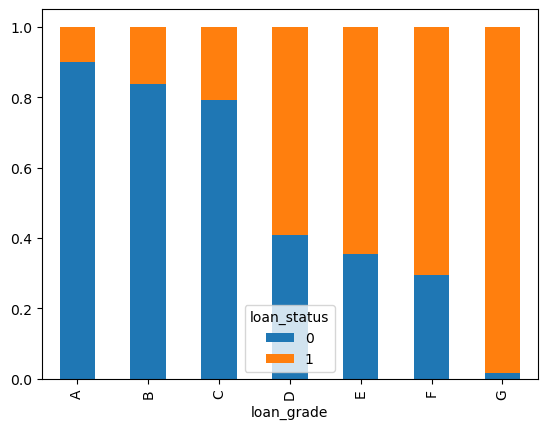

In [26]:
pd.crosstab(
    df["loan_grade"],
    df["loan_status"],
    normalize="index"
).plot(kind="bar", stacked= True)

<Axes: xlabel='cb_person_default_on_file'>

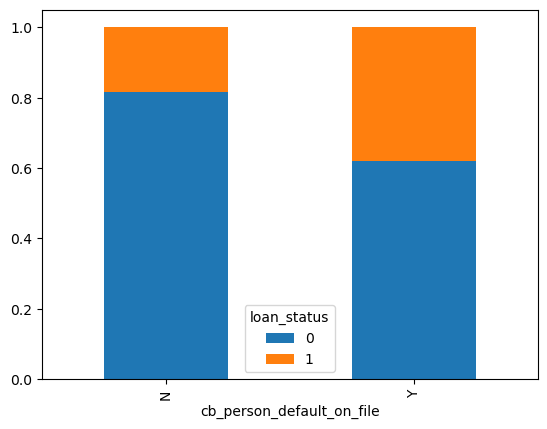

In [27]:
pd.crosstab(
    df["cb_person_default_on_file"],
    df["loan_status"],
    normalize="index"
).plot(kind="bar", stacked= True)

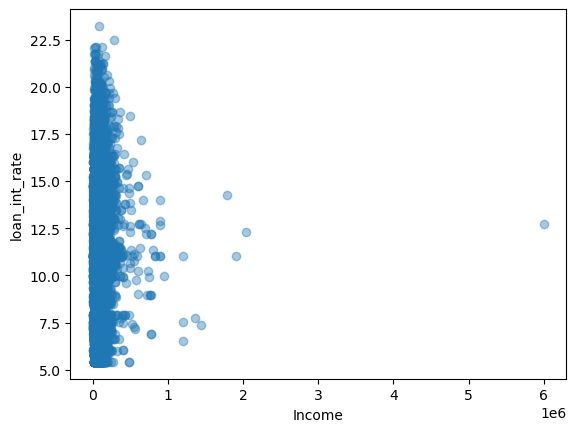

In [29]:
plt.Figure(figsize=(8,6))

plt.scatter(
    df["person_income"],
    df["loan_int_rate"],
    alpha=0.4
)

plt.xlabel("Income")
plt.ylabel("loan_int_rate")
plt.show()

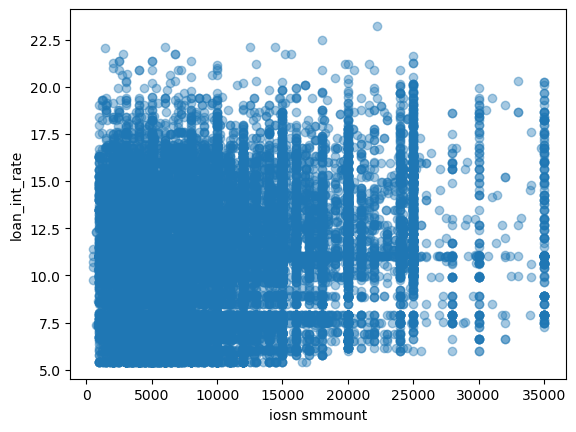

In [30]:
plt.Figure(figsize=(8,6))

plt.scatter(
    df["loan_amnt"],
    df["loan_int_rate"],
    alpha=0.4
)

plt.xlabel("iosn smmount")
plt.ylabel("loan_int_rate")
plt.show()

In [31]:
df.to_csv("tran_default.csv", index=False)